<div align="center">

## Zadanie 1

</div>

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.cluster import KMeans

# Załadowanie danych
digits = load_digits()
images = digits.data
targets = digits.target

def get_semi_targets(targets, labeled_ratio = 0.05):
    # Losujemy indeksy, które zostaną etykietowane
    n_samples = len(targets)
    n_labeled = int(n_samples * labeled_ratio)

    rng = np.random.default_rng(seed=42)  # dla powtarzalności
    labeled_indices = rng.choice(n_samples, size=n_labeled, replace=False)

    semi_targets = np.full_like(targets, fill_value=-1)

    semi_targets[labeled_indices] = targets[labeled_indices]

    print("Liczba etykietowanych:", np.sum(semi_targets != -1))
    print("Liczba nieetykietowanych:", np.sum(semi_targets == -1))

    return semi_targets, labeled_indices

semi_targets, labeled_indices = get_semi_targets(targets=targets, labeled_ratio = 0.05)

Liczba etykietowanych: 89
Liczba nieetykietowanych: 1708


<div>

### Podpunkt B

</div>

In [2]:
def get_labels_from_model_1(images, semi_targets):
    kmeans = KMeans(n_clusters=10, random_state=42)
    labels = kmeans.fit_predict(images)

    propagated_labels = np.copy(semi_targets)

    for cluster_id in range(10):
        cluster_points = np.where(labels == cluster_id)[0]  # punkty w klastrze

        # punkty z etykietą w tym klastrze
        labeled_points = [i for i in cluster_points if semi_targets[i] != -1]

        if len(labeled_points) == 0:
            # brak etykiet w tym klastrze - pominąć
            continue

        # policz częstotliwości etykiet
        cluster_true_labels = semi_targets[labeled_points]
        most_common = np.bincount(cluster_true_labels).argmax()

        # przypisz tę etykietę wszystkim punktom w klastrze
        propagated_labels[cluster_points] = most_common

    return propagated_labels

propagated_labels_c1 = get_labels_from_model_1(images, semi_targets)

# Wynik propagacji
print("\nPrzykładowe propagowane etykiety:")
print(propagated_labels_c1[:50])




Przykładowe propagowane etykiety:
[0 1 1 3 4 9 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 9 5 5 6 5 0
 9 8 9 8 4 1 7 7 3 5 1 0 0]


<div>

### Podpunkt C

</div>

In [3]:
def get_labels_from_model_2(images, semi_targets):
    kmeans = KMeans(n_clusters=10, random_state=42)
    labels = kmeans.fit_predict(images)
    centroids = kmeans.cluster_centers_

    propagated_labels = np.full_like(semi_targets, fill_value=-1)
    cluster_labels = {}  # będzie przechowywać wynikowe etykiety klastrów

    # 1. Najpierw oznacz klastry, które mają etykiety (jak majority vote)
    for cluster_id in range(10):
        cluster_points = np.where(labels == cluster_id)[0]
        labeled_points = [i for i in cluster_points if semi_targets[i] != -1]

        if len(labeled_points) == 0:
            continue

        # majority vote
        cluster_true_labels = semi_targets[labeled_points]
        most_common = np.bincount(cluster_true_labels).argmax()
        cluster_labels[cluster_id] = most_common

    # 2. Klastry bez etykiet - używamy najbliższego centroidu
    for cluster_id in range(10):
        if cluster_id in cluster_labels:
            continue

        # Odległość centroidu tego klastra do centroidów klastrów oznaczonych
        distances = []
        for labeled_cluster in cluster_labels:
            dist = np.linalg.norm(centroids[cluster_id] - centroids[labeled_cluster])
            distances.append((dist, labeled_cluster))

        # Najbliższy klaster
        _, nearest_cluster = min(distances, key=lambda x: x[0])
        cluster_labels[cluster_id] = cluster_labels[nearest_cluster]

    # 3. Przypisz etykiety do punktów na podstawie cluster_labels
    for i in range(len(semi_targets)):
        propagated_labels[i] = cluster_labels[labels[i]]

    return propagated_labels
    
propagated_labels_c2 = get_labels_from_model_2(images, semi_targets)

# Gotowe
print("Etykiety po propagacji (c2):")
print(propagated_labels_c2[:50])

Etykiety po propagacji (c2):
[0 1 1 3 4 9 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 1 2 3 4 5 6 7 8 9 0 9 5 5 6 5 0
 9 8 9 8 4 1 7 7 3 5 1 0 0]


In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

unlabeled_mask = semi_targets == -1

print(f'Model 1 accuracy: {accuracy_score(propagated_labels_c1[unlabeled_mask], targets[unlabeled_mask]):.02f}')
print(f'Model 2 accuracy: {accuracy_score(propagated_labels_c2[unlabeled_mask], targets[unlabeled_mask]):.02f}')

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(images[labeled_indices], targets[labeled_indices])

knn_predictions = knn.predict(images)
print(f'Trenowany na etykietach Model KNN  accuracy: {accuracy_score(knn_predictions[unlabeled_mask], targets[unlabeled_mask]):.02f}')

knn_full = KNeighborsClassifier(n_neighbors=5)
knn_full.fit(images, targets)

knn_full_pred = knn_full.predict(images)

print(f'Nadzorowany Model KNN  accuracy: {accuracy_score(knn_full_pred[unlabeled_mask], targets[unlabeled_mask]):.02f}')


Model 1 accuracy: 0.86
Model 2 accuracy: 0.86
Trenowany na etykietach Model KNN  accuracy: 0.81
Nadzorowany Model KNN  accuracy: 0.99


In [5]:
res = []

for ratio in [0.01, 0.05, 0.10, 0.20]:
    semi_targets, labeled_indices = get_semi_targets(targets, labeled_ratio = ratio)
    
    pred_1 = get_labels_from_model_1(images, semi_targets)
    pred_2 = get_labels_from_model_2(images, semi_targets)

    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(images[labeled_indices], targets[labeled_indices])
    knn_pred = knn.predict(images)

    print(f'RATIO: {ratio}')
    print(f'Model 1 accuracy: {100 * accuracy_score(pred_1[unlabeled_mask], targets[unlabeled_mask]):.02f}%')
    print(f'Model 2 accuracy: {100 * accuracy_score(pred_2[unlabeled_mask], targets[unlabeled_mask]):.02f}%')
    print(f'Model 3 accuracy: {100 * accuracy_score(knn_pred[unlabeled_mask], targets[unlabeled_mask]):.02f}%')
    print()
    

Liczba etykietowanych: 17
Liczba nieetykietowanych: 1780
RATIO: 0.01
Model 1 accuracy: 71.43%
Model 2 accuracy: 71.60%
Model 3 accuracy: 32.85%

Liczba etykietowanych: 89
Liczba nieetykietowanych: 1708
RATIO: 0.05
Model 1 accuracy: 86.18%
Model 2 accuracy: 86.18%
Model 3 accuracy: 80.74%

Liczba etykietowanych: 179
Liczba nieetykietowanych: 1618
RATIO: 0.1
Model 1 accuracy: 86.18%
Model 2 accuracy: 86.18%
Model 3 accuracy: 91.57%

Liczba etykietowanych: 359
Liczba nieetykietowanych: 1438
RATIO: 0.2
Model 1 accuracy: 86.18%
Model 2 accuracy: 86.18%
Model 3 accuracy: 95.78%



<div align="center">

## Zadanie 2

</div>

In [6]:
import numpy as np
import pandas as pd
import plotly.express as px

rng = np.random.default_rng(42)

n_trams = 200

# Normalne dane
temperature = rng.normal(loc=60, scale=5, size=n_trams)   # 60°C średnia
vibration = rng.normal(loc=2.0, scale=0.3, size=n_trams)  # wibracje (g)
speed = rng.normal(loc=40, scale=3, size=n_trams)         # km/h

# Wprowadzamy anomalie losowo u ~10 tramwajów
n_anomalies = 10
anomaly_idx = rng.choice(n_trams, n_anomalies, replace=False)

temperature[anomaly_idx] += rng.normal(20, 5, size=n_anomalies)  # przegrzewanie
vibration[anomaly_idx] += rng.normal(1.5, 0.2, size=n_anomalies) # drgania
speed[anomaly_idx] -= rng.normal(10, 3, size=n_anomalies)        # spadek prędkości

# Zbuduj DataFrame
df = pd.DataFrame({
    "temperature": temperature,
    "vibration": vibration,
    "speed": speed,
    "is_anomaly": [1 if i in anomaly_idx else 0 for i in range(n_trams)]
})

print(df.head())
print("\nLiczba anomalii:", df["is_anomaly"].sum())

trams = np.array(df[["temperature", "vibration", "speed"]])
test = np.ravel(np.array(df[["is_anomaly"]]))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(trams)
trams = scaler.transform(trams)

fig = px.scatter_3d(
    df,
    x="temperature",
    y="vibration",
    z="speed",
    color="temperature",                 # użyj koloru opartego na danych
    color_continuous_scale="jet",        # mapa kolorów "jet"
)

fig.update_traces(
    marker=dict(
        size=4,                          # mniejsze punkty
        opacity=0.9
    )
)

fig.update_layout(
    scene=dict(
        xaxis_title="Temperature",
        yaxis_title="Vibration",
        zaxis_title="Speed",
        xaxis=dict(
            backgroundcolor="black",
            color="white",
            gridcolor="gray"
        ),
        yaxis=dict(
            backgroundcolor="black",
            color="white",
            gridcolor="gray"
        ),
        zaxis=dict(
            backgroundcolor="black",
            color="white",
            gridcolor="gray"
        )
    ),
    paper_bgcolor="black",                # tło całej figury
    plot_bgcolor="black",
)

fig.show()


   temperature  vibration      speed  is_anomaly
0    61.523585   2.101272  39.461166           0
1    54.800079   2.422245  40.590328           0
2    63.752256   2.027175  42.461585           0
3    64.702824   2.193182  38.818776           0
4    50.244824   1.384948  41.563502           0

Liczba anomalii: 10


<div align="center">

Metoda K-Means

</div>

In [7]:
from sklearn.cluster import KMeans

def get_kmeans_pred(data, n_clusters=1, percentile=95):
    # Dopasowanie K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(data)

    # Odległość każdego punktu od najbliższego centroidu
    distances = np.min(
        np.linalg.norm(data[:, None] - kmeans.cluster_centers_, axis=2),
        axis=1
    )    

    # Ustalenie progu np. 95. percentyla
    threshold = np.percentile(distances, percentile)

    # Punkty powyżej tego progu to anomalie
    anomalies = (distances > threshold).astype(int)

    return anomalies

kmeans_pred = get_kmeans_pred(trams)

<div align="center">

Metoda DBSCAN

</div>

In [8]:
from sklearn.cluster import DBSCAN

def get_dbscan_pred(data):
    dbscan = DBSCAN(eps=1.2, min_samples=6).fit(data)
    dbscan_pred = (dbscan.labels_ == -1).astype(int)

    return dbscan_pred

dbscan_pred = get_dbscan_pred(trams)

<div align="center">

Metoda LOF (Local Outliner Factor)

</div>

In [9]:
from sklearn.neighbors import LocalOutlierFactor

def get_lof_pred(data):
    lof = LocalOutlierFactor(
        n_neighbors=15,
        contamination=0.05,
    )

    pred = lof.fit_predict(data)

    pred = (pred == -1).astype(int)  # konwersja na 0/1 żeby porównać z test

    return pred

lof_pred = get_lof_pred(trams)

<div align="center">

Analiza porównawacza

</div>

In [10]:
from sklearn.metrics import precision_score, recall_score, f1_score

kmeans_recall = recall_score(test, kmeans_pred)
kmeans_precision = precision_score(test, kmeans_pred)
kmeans_f1 = f1_score(test, kmeans_pred)

dbscan_recall = recall_score(test, dbscan_pred)
dbscan_precision = precision_score(test, dbscan_pred)
dbscan_f1 = f1_score(test, dbscan_pred)

lof_recall = recall_score(test, lof_pred)
lof_precision = precision_score(test, lof_pred)
lof_f1 = f1_score(test, lof_pred)

print("K-Means wyniki:")
print(f"Recall: {100 * kmeans_recall:.02f}%")
print(f"Precision: {100 * kmeans_precision:.02f}%")
print(f"F1: {100 * kmeans_f1:.02f}%")
print()

print("DBSCAN wyniki:")
print(f"Recall: {100 * dbscan_recall:.02f}%")
print(f"Precision: {100 * dbscan_precision:.02f}%")
print(f"F1: {100 * dbscan_f1:.02f}%")
print()

print("LOF wyniki:")
print(f"Recall: {100 * lof_recall:.02f}%")
print(f"Precision: {100 * lof_precision:.02f}%")
print(f"F1: {100 * lof_f1:.02f}%")

K-Means wyniki:
Recall: 100.00%
Precision: 100.00%
F1: 100.00%

DBSCAN wyniki:
Recall: 100.00%
Precision: 100.00%
F1: 100.00%

LOF wyniki:
Recall: 100.00%
Precision: 100.00%
F1: 100.00%


**W tym scenariuszu najlepiej wykrywa metoda DBSCAN, ponieważ wykrywa wszystkie awarie oraz dodatkowo ma wysoki F1-score. Co prawda wykrywa trochę false positives, ale w tym scenariuszu chcemy, wykrywać błędy wcześniej, ponieważ lepiej jest unikąć sporych kosztów naprawy. Oto z tych powodów wydaje mi się, że to najelepsza metoda. Plus DBSCAN szczerze chyba, podoba mi się najbardziej ze wszystkich algorytmów. TBH jest GOATem. Jakby fajne jest to, że klastruje nie tylko w kółka, jakby czy coś w rzeczywistości ma dokładnie kształ koła? Chociaż teraz się pobawiłem i przeskalowałem wartości? Wszystko daje 100 procent? Crazy!!!**

<div align="center">

## Zadanie 3

</div>

In [11]:
import numpy as np

def generate_trajectories(n_trajectories=50, random_state=42):
    """Generuje syntetyczne trajektorie GPS."""
    np.random.seed(random_state)
    trajectories = []

    # Typ 1: Trasa do centrum
    for _ in range(15):
        length = np.random.randint(20, 40)
        start = np.random.randn(2) * 5 + [10, 10]
        end = np.array([0, 0])
        t = np.linspace(0, 1, length).reshape(-1, 1)
        traj = start + t * (end - start) + np.random.randn(length, 2) * 0.3
        trajectories.append(traj)

    # Typ 2: Trasa rekreacyjna (pętla)
    for _ in range(15):
        length = np.random.randint(30, 50)
        t = np.linspace(0, 2 * np.pi, length)
        r = 3 + np.random.rand() * 2
        traj = np.column_stack([r * np.cos(t), r * np.sin(t)])
        traj += np.random.randn(length, 2) * 0.2
        trajectories.append(traj)

    # Typ 3: Trasa wzdłuż rzeki (liniowa)
    for _ in range(20):
        length = np.random.randint(25, 45)
        start_x = np.random.rand() * 10 - 5
        traj = np.column_stack([
            np.linspace(start_x, start_x + 8, length),
            np.sin(np.linspace(0, np.pi, length)) * 2
        ])
        traj += np.random.randn(length, 2) * 0.2
        trajectories.append(traj)

    return trajectories


trajectories = generate_trajectories()

In [12]:
import numpy as np

def dtw_dist(traj1, traj2):
    n, m = len(traj1), len(traj2)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0

    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = np.linalg.norm(traj1[i-1] - traj2[j-1])
            D[i, j] = cost + min(
                D[i-1, j],
                D[i, j-1],
                D[i-1, j-1]
            )

    return D[n, m]

In [13]:
n = len(trajectories)
dtw_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(i + 1,  n):
        dtw_matrix[i, j] = dtw_dist(trajectories[i], trajectories[j])
        dtw_matrix[j, i] = dtw_matrix[i, j]

print(dtw_matrix)

[[  0.         129.32732942  71.50665075 ... 201.02621009 304.648609
  224.81634662]
 [129.32732942   0.         123.5124904  ...  77.20915891 290.93599776
  104.56389712]
 [ 71.50665075 123.5124904    0.         ... 184.5357782  246.092775
  195.02084624]
 ...
 [201.02621009  77.20915891 184.5357782  ...   0.         294.03381501
   35.09073846]
 [304.648609   290.93599776 246.092775   ... 294.03381501   0.
  261.12143696]
 [224.81634662 104.56389712 195.02084624 ...  35.09073846 261.12143696
    0.        ]]


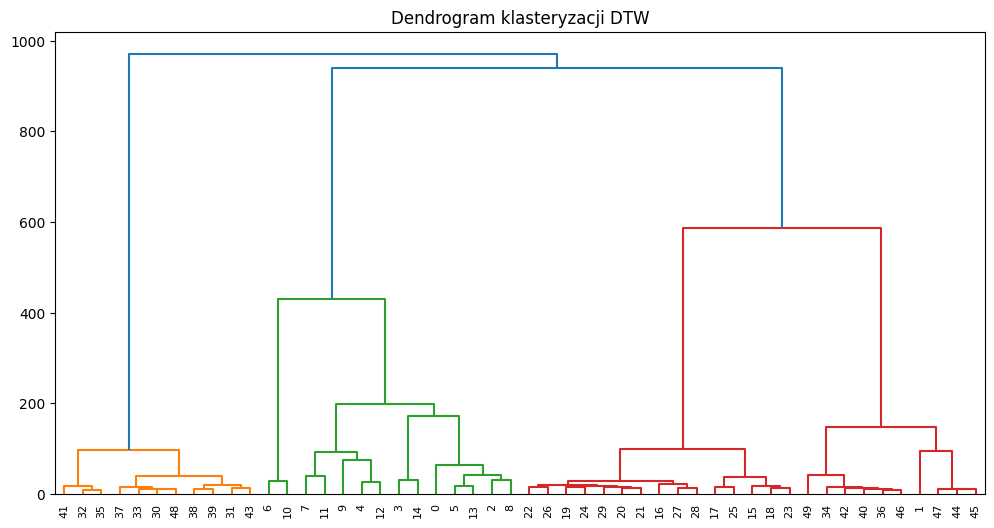

[2 3 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 1 1 1 1 3 1 3
 1 1 1 3 1 3 1 3 3 3 3 1 3]


In [14]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

dist_vector = squareform(dtw_matrix)


Z = linkage(dist_vector, method='ward')


plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Dendrogram klasteryzacji DTW")
plt.show()


clusters = fcluster(Z, t=3, criterion='maxclust')
print(clusters)

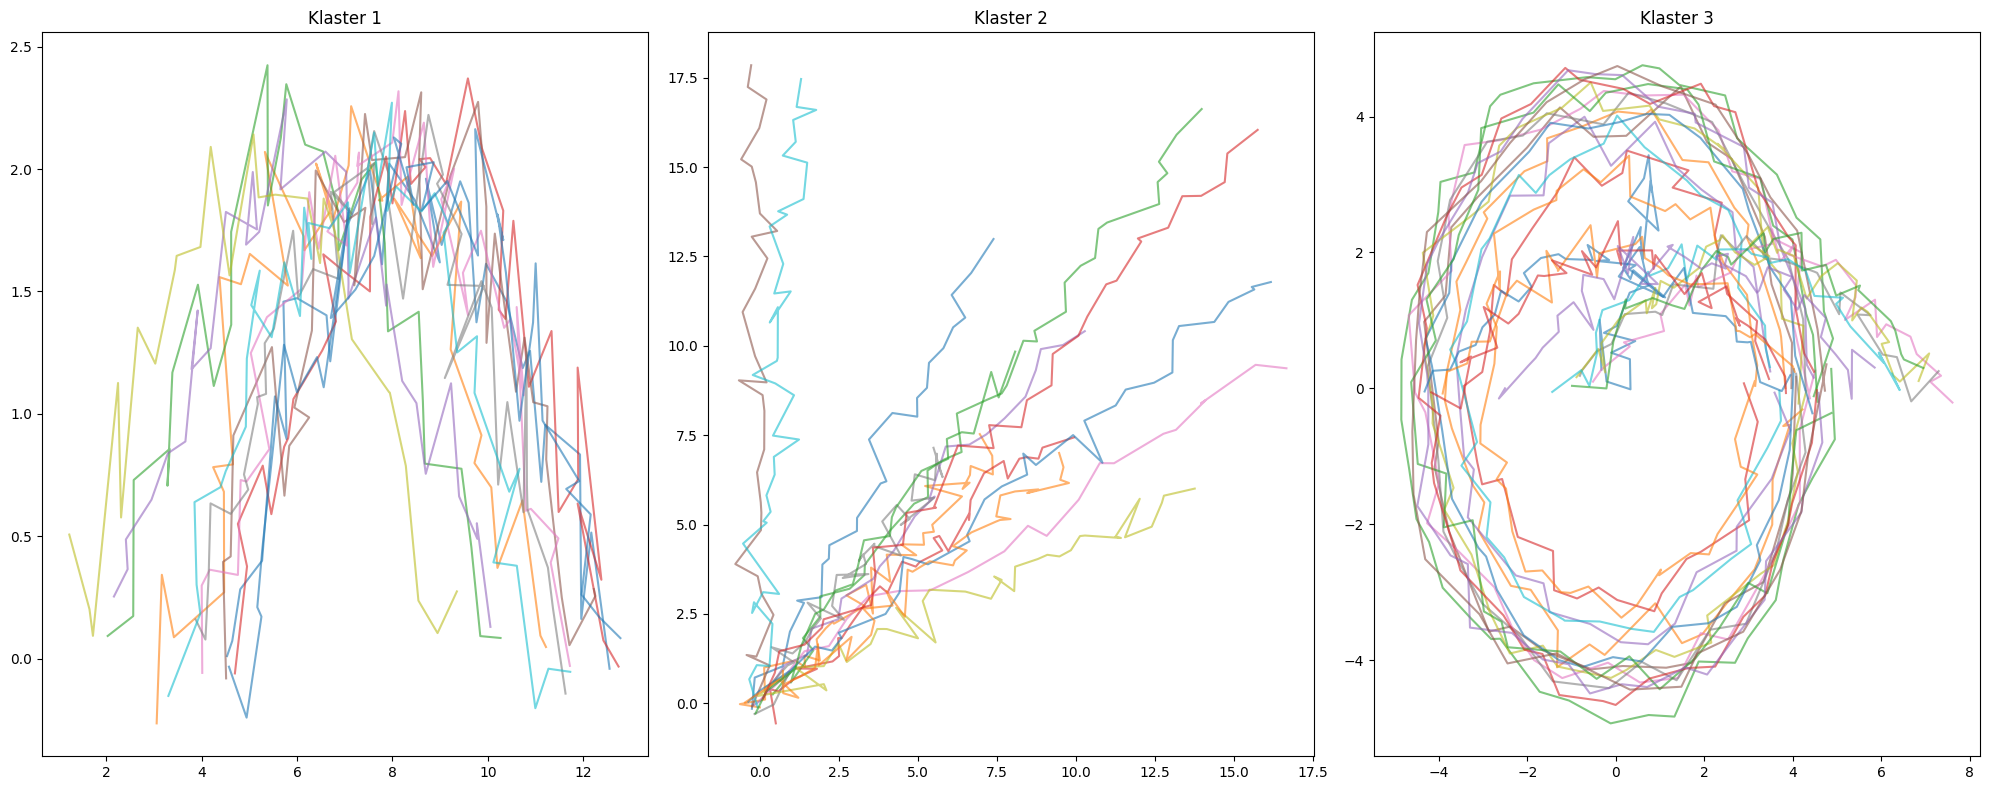

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

for k in np.unique(clusters):
    ax = axs[k - 1]
    for i, traj in enumerate(trajectories):
        if clusters[i] == k:
            ax.plot(traj[:, 0], traj[:, 1], alpha=0.6)
    ax.set_title(f"Klaster {k}")

plt.tight_layout()
plt.show()

<div align="center">

## Zadanie 4

</div>

In [16]:
import pandas as pd
import time
import psutil
import os

# -------------------------------------
# Funkcja pomocnicza: pamięć procesu
# -------------------------------------
def get_memory_mb():
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)

# -------------------------------------
# Start pomiarów
# -------------------------------------
mem_before = get_memory_mb()
t_start = time.time()

# -------------------------------------
# Wczytanie danych
# -------------------------------------
df = pd.read_csv('wroshop_small.csv')

# -------------------------------------
# Operacja 1: groupby po kategorii
# -------------------------------------
grouped = df.groupby('category').agg({
    'price': ['mean', 'min', 'max', 'count']
})

# -------------------------------------
# Operacja 2: top 10 miast
# -------------------------------------
top_cities = df['city'].value_counts().head(10)

# -------------------------------------
# Operacja 3: filtrowanie
# (np. produkty droższe niż 10 zł)
# -------------------------------------
filtered = df[df['price'] > 10.0]

# -------------------------------------
# Koniec pomiarów
# -------------------------------------
t_end = time.time()
mem_after = get_memory_mb()

# -------------------------------------
# Wyniki
# -------------------------------------
print("=== GROUPBY ===")
print(grouped, "\n")

print("=== TOP 10 MIAST ===")
print(top_cities, "\n")

print("=== FILTROWANIE (price > 10) ===")
print(filtered.head(), "\n")

print("=== STATYSTYKI ===")
print(f"Czas wykonania: {t_end - t_start:.4f} s")
print(f"Zużycie pamięci: {mem_after - mem_before:.2f} MB")


=== GROUPBY ===
                         price                      
                          mean     min     max count
category                                            
AGD                 237.211262  151.05  417.27  4619
Artykuly_Spozywcze   35.921216   10.24   90.31  4776
Dom_i_Ogrod         120.338454   31.58  309.49  3668
Elektronika         285.821397  200.49  467.11  7371
Filmy                42.499776   20.34   91.85  2762
Gry                 107.172418   50.13  233.96  5574
Komputery           356.746611  300.54  465.35  5585
Ksiazki              29.856139   10.25   73.22  7378
Moda_Damska          78.781490   30.28  174.95  6458
Moda_Meska          100.097411   40.22  218.32  5535
Motoryzacja         148.854629   51.04  366.00  2722
Muzyka               39.233461   15.66   88.86  2823
Obuwie              121.628740   50.58  274.29  4594
RTV                 284.827958  201.27  462.31  4637
Smartfony           428.653071  400.06  490.23  9301
Sport               136.923927

In [17]:
import time
import pandas as pd
import glob

# -------------------------
# Wczytywanie wielu plików z katalogu
# -------------------------

start_time = time.time()

file_list = glob.glob("wroshop_medium/*.csv")
print(f"Liczba plików: {len(file_list)}")

df_list = [pd.read_csv(f) for f in file_list]
df_big = pd.concat(df_list, ignore_index=True)

load_time = time.time() - start_time
print(f"Wczytywanie dużego zbioru (1M+): {load_time:.4f} s")

# -------------------------
# Pomiar pamięci
# -------------------------
mem = df_big.memory_usage(deep=True).sum() / (1024**2)
print(f"Zużycie pamięci: {mem:.2f} MB")

# -------------------------
# Operacje takie same jak w 100k
# -------------------------

# Groupby
start = time.time()
grouped_big = df_big.groupby("category").agg({
    "price": ["mean", "min", "max"],
    "product_id": "count"
})
t_groupby = time.time() - start

# Top 10 cities
start = time.time()
top_cities_big = df_big["city"].value_counts().head(10)
t_top = time.time() - start

# Filtrowanie
start = time.time()
filtered_big = df_big[df_big["price"] > 10]
t_filter = time.time() - start

print("\nWyniki na dużym zbiorze (1M):")
print("-----------------------------")
print(f"Groupby: {t_groupby:.4f} s")
print(f"Top 10 miast: {t_top:.4f} s")
print(f"Filtrowanie: {t_filter:.4f} s")


Liczba plików: 10
Wczytywanie dużego zbioru (1M+): 1.0198 s
Zużycie pamięci: 368.47 MB

Wyniki na dużym zbiorze (1M):
-----------------------------
Groupby: 0.0540 s
Top 10 miast: 0.0319 s
Filtrowanie: 0.0319 s


Czas Dask: 2.6300160884857178
category
AGD                    567.262424
Artykuly_Spozywcze      86.639367
Dom_i_Ogrod            292.902007
Elektronika            691.361789
Filmy                  103.830486
Gry                    259.026620
Komputery              860.529927
Ksiazki                 72.774839
Moda_Damska            189.625304
Moda_Meska             241.676379
Motoryzacja            365.286518
Muzyka                  94.984214
Obuwie                 293.099107
RTV                    688.030646
Smartfony             1031.729203
Sport                  326.356896
Uroda                  172.295154
Zabawki                173.225284
Zdrowie                129.935982
Zwierzeta              129.465121
Name: total_amount, dtype: float64


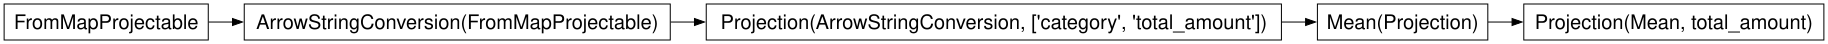

In [18]:
import dask.dataframe as dd
import time

start = time.time()

# Wczytanie wielu plików naraz
ddf = dd.read_csv("wroshop_medium/*.csv")

# Przykładowe operacje
result_groupby = ddf.groupby("category")["total_amount"].mean().compute()
top_cities = ddf["city"].value_counts().nlargest(10).compute()
filtered = ddf[ddf["total_amount"] > 500].compute()

end = time.time()

print("Czas Dask:", end - start)
print(result_groupby)

ddf.groupby("category")["total_amount"].mean().visualize(rankdir="LR")

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("WroShop") \
    .getOrCreate()

df = spark.read.csv(
    "wroshop_medium/",
    header=True,
    inferSchema=True
)

# Operacja grupująca
result = df.groupBy("category").avg("total_amount")

result.show()

# Plan wykonania (fizyczny i logiczny)
result.explain()


<div align="center">

## Zadanie 5

</div>

<div align="center">

Softmax Attention

</div>

In [20]:
import numpy as np
from scipy.special import softmax
import time

def softmax_my(x, axis=None):
    x_max = np.max(x, axis=axis, keepdims=True)
    e = np.exp(x - x_max)
    return e / np.sum(e, axis=axis, keepdims=True)

def attention_matrix(Q, K, V):
    d_k = Q.shape[1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    return weights @ V

def attention_matrix(Q, K, V):
    d_k = Q.shape[1]
    scores = Q @ K.T / np.sqrt(d_k)
    weights = softmax(scores, axis=-1)
    return weights @ V

def attention_loops(Q, K, V):
    n, d_k = Q.shape
    scores = np.zeros((n, n))

    # 1. Obliczamy QK^T / sqrt(dk)
    for i in range(n):
        for j in range(n):
            scores[i, j] = np.dot(Q[i], K[j]) / np.sqrt(d_k)

    # 2. Softmax wzdłuż wierszy
    weights = np.zeros_like(scores)
    for i in range(n):
        weights[i] = softmax(scores[i])

    # 3. Mnożenie przez V
    out = np.zeros_like(Q)
    for i in range(n):
        for j in range(n):
            out[i] += weights[i, j] * V[j]

    return out

def benchmark(n, d=64):
    Q = np.random.randn(n, d)
    K = np.random.randn(n, d)
    V = np.random.randn(n, d)

    print("\n==============================================")
    print(f"Benchmark Attention - n = {n}, d = {d}")
    print("==============================================")

    # macierzowo
    t0 = time.time()
    out_mat = attention_matrix(Q, K, V)
    t1 = time.time()
    print(f"Macierzowo: {t1 - t0:.6f} s")

    # naiwne pętle
    t2 = time.time()
    out_loop = attention_loops(Q, K, V)
    t3 = time.time()
    print(f"Pętle:      {t3 - t2:.6f} s")

    # weryfikacja poprawności
    ok = np.allclose(out_mat, out_loop, atol=1e-5)
    diff = np.max(np.abs(out_mat - out_loop))

    print("\n--- Walidacja poprawności ---")
    print(f"np.allclose:   {ok}")
    print(f"maks. różnica: {diff:.8f}")
    print("----------------------------------------------")

for n in [64, 256, 512]:
    benchmark(n)


Benchmark Attention - n = 64, d = 64
Macierzowo: 0.000999 s
Pętle:      0.008650 s

--- Walidacja poprawności ---
np.allclose:   True
maks. różnica: 0.00000000
----------------------------------------------

Benchmark Attention - n = 256, d = 64
Macierzowo: 0.001513 s
Pętle:      0.155560 s

--- Walidacja poprawności ---
np.allclose:   True
maks. różnica: 0.00000000
----------------------------------------------

Benchmark Attention - n = 512, d = 64
Macierzowo: 0.004044 s
Pętle:      0.629343 s

--- Walidacja poprawności ---
np.allclose:   True
maks. różnica: 0.00000000
----------------------------------------------


<div align="center">

Confusion Matrix

</div>

In [21]:
import numpy as np
import time

def confusion_matrix_naive(true_values, pred_values, k):
    n = len(true_values)
    confusion_matrix = np.zeros(shape=(k, k), dtype=int)

    for i in range(n):
        x = true_values[i]
        y = pred_values[i]
        confusion_matrix[x][y] += 1

    return confusion_matrix

def confusion_matrix(true_values, pred_values, k):
    n = len(true_values)

    matrix_true = np.zeros(shape=(n, k), dtype=int)
    matrix_pred = np.zeros(shape=(n, k), dtype=int)
    
    matrix_true[np.arange(n), true_values] = 1
    matrix_pred[np.arange(n), pred_values] = 1

    return matrix_true.T @ matrix_pred

def confusion_matrix_fast(true, pred, k):
    return np.bincount(true * k + pred, minlength=k*k).reshape(k, k)

def benchmark(N, K):
    print(f"Benchmark: N={N}, K={K}")

    y_true = np.random.choice(K, size=N)
    y_pred = np.random.choice(K, size=N)

    start = time.time()
    cmn = confusion_matrix_naive(y_true, y_pred, K)
    end = time.time()


    print('IMPLEMENTACJA NAIWNA')
    print("Czas:", round(end - start, 4), "sek")
    print("Macierz shape:", cmn.shape)
    print(cmn)
    print()

    start = time.time()
    cm = confusion_matrix(y_true, y_pred, K)
    end = time.time()

    print("IMPLEMENTACJA MACIERZOWA")
    print("Czas:", round(end - start, 4), "sek")
    print("Macierz shape:", cm.shape)
    print(cm)
    print()

    start = time.time()
    cmf = confusion_matrix_fast(y_true, y_pred, K)
    end = time.time()

    print("IMPLEMENTACJA SZYBKA")
    print("Czas:", round(end - start, 4), "sek")
    print("Macierz shape:", cmf.shape)
    print(cmf)
    print("OK: ", np.allclose(cmn, cm, atol=1e-6))
    print()
    print("---")

# Testy wymagane w zadaniu
for N in [10_000, 100_000]:
    for K in [10, 50, 100]:
        benchmark(N, K)


Benchmark: N=10000, K=10
IMPLEMENTACJA NAIWNA
Czas: 0.0035 sek
Macierz shape: (10, 10)
[[ 86 108  95 122  95 101  91 109  89 105]
 [ 86  97  95 109 107 100 104 104  98  96]
 [115 107 113 111  92 104 107  95 100  99]
 [ 92  98 102  86 106 100  98  97 111  96]
 [103 108 101 113 102 101 100  96 114  98]
 [102 112 100  96  87 103 103 115  90  82]
 [107  87 100  86  96 105 106  97  87  99]
 [103  97 108  78 103  94  89  99 117  90]
 [106 116 101  87  97  98  79 130  99  93]
 [115  91  98  91 110  84 106 102 100  97]]

IMPLEMENTACJA MACIERZOWA
Czas: 0.001 sek
Macierz shape: (10, 10)
[[ 86 108  95 122  95 101  91 109  89 105]
 [ 86  97  95 109 107 100 104 104  98  96]
 [115 107 113 111  92 104 107  95 100  99]
 [ 92  98 102  86 106 100  98  97 111  96]
 [103 108 101 113 102 101 100  96 114  98]
 [102 112 100  96  87 103 103 115  90  82]
 [107  87 100  86  96 105 106  97  87  99]
 [103  97 108  78 103  94  89  99 117  90]
 [106 116 101  87  97  98  79 130  99  93]
 [115  91  98  91 110  84 106

In [22]:
import numpy as np
import time

def batchnorm_matrix(X, eps=1e-5):
    # X: (batch, features)
    mean = X.mean(axis=0)
    var = X.var(axis=0)
    X_norm = (X - mean) / np.sqrt(var + eps)
    return X_norm

def batchnorm_loops(X, eps=1e-5):
    batch, features = X.shape
    
    # mean
    mean = np.zeros(features)
    for j in range(features):
        s = 0
        for i in range(batch):
            s += X[i, j]
        mean[j] = s / batch

    # variance
    var = np.zeros(features)
    for j in range(features):
        s = 0
        for i in range(batch):
            s += (X[i, j] - mean[j])**2
        var[j] = s / batch

    # normalize
    X_norm = np.zeros_like(X)
    for i in range(batch):
        for j in range(features):
            X_norm[i, j] = (X[i, j] - mean[j]) / np.sqrt(var[j] + eps)

    return X_norm

def benchmark(batch, features):
    print("\n============================================")
    print(f"BatchNorm benchmark: batch={batch}, features={features}")
    print("============================================")

    X = np.random.randn(batch, features)

    # Macierzowo
    t0 = time.time()
    out_mat = batchnorm_matrix(X)
    t1 = time.time()
    print(f"Macierzowo: {t1 - t0:.6f} s")

    # Pętle
    t2 = time.time()
    out_loop = batchnorm_loops(X)
    t3 = time.time()
    print(f"Pętle:      {t3 - t2:.6f} s")

    # Walidacja
    ok = np.allclose(out_mat, out_loop, atol=1e-5)
    diff = np.max(np.abs(out_mat - out_loop))

    print("\n--- Walidacja poprawności ---")
    print(f"np.allclose:   {ok}")
    print(f"maks. różnica: {diff:.8f}")
    print("--------------------------------------------")

benchmark(batch=128, features=1024)
benchmark(batch=128, features=4096)



BatchNorm benchmark: batch=128, features=1024
Macierzowo: 0.001501 s
Pętle:      0.131510 s

--- Walidacja poprawności ---
np.allclose:   True
maks. różnica: 0.00000000
--------------------------------------------

BatchNorm benchmark: batch=128, features=4096
Macierzowo: 0.003013 s
Pętle:      0.553941 s

--- Walidacja poprawności ---
np.allclose:   True
maks. różnica: 0.00000000
--------------------------------------------



PageRank benchmark: n=200, iters=50
Macierzowo: 0.000998 s
Pętle:      0.402915 s

--- Walidacja poprawności ---
np.allclose:   True
maks. różnica: 0.00000000


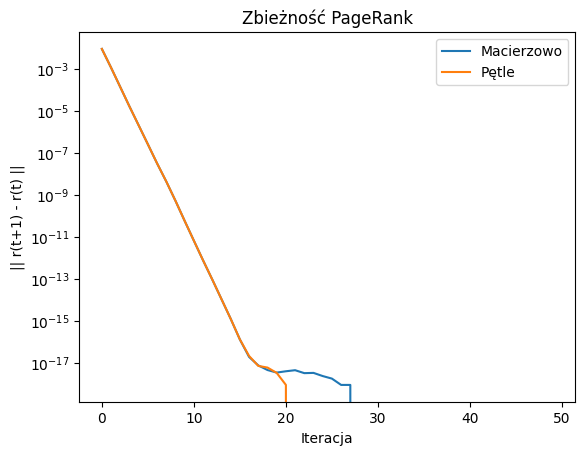

In [23]:
import numpy as np
import time
import matplotlib.pyplot as plt

def generate_transition_matrix(n, p=0.2):
    A = (np.random.rand(n, n) < p).astype(float)  # macierz sąsiedztwa
    A[A.sum(axis=0) == 0] = 1  # zapobiega kolumnom bez wyjść
    M = A / A.sum(axis=0, keepdims=True)
    return M

def pagerank_matrix(M, d=0.85, iters=50):
    n = M.shape[0]
    r = np.ones(n) / n
    history = []

    for _ in range(iters):
        r_new = d * M @ r + (1-d)/n
        history.append(np.linalg.norm(r_new - r))
        r = r_new

    return r, history

def pagerank_loops(M, d=0.85, iters=50):
    n = M.shape[0]
    r = np.ones(n) / n
    history = []

    for _ in range(iters):
        r_new = np.zeros(n)
        
        # naiwne mnożenie M @ r
        for i in range(n):
            for j in range(n):
                r_new[i] += M[i, j] * r[j]

        # tłumienie
        for i in range(n):
            r_new[i] = d * r_new[i] + (1-d)/n

        history.append(np.linalg.norm(r_new - r))
        r = r_new

    return r, history

def benchmark(n=200, iters=50):
    print("\n==============================================")
    print(f"PageRank benchmark: n={n}, iters={iters}")
    print("==============================================")

    M = generate_transition_matrix(n)

    # --- macierzowo ---
    t0 = time.time()
    r_mat, hist_mat = pagerank_matrix(M, iters=iters)
    t1 = time.time()
    print(f"Macierzowo: {t1 - t0:.6f} s")

    # --- pętle ---
    t2 = time.time()
    r_loop, hist_loop = pagerank_loops(M, iters=iters)
    t3 = time.time()
    print(f"Pętle:      {t3 - t2:.6f} s")

    # --- poprawność ---
    ok = np.allclose(r_mat, r_loop, atol=1e-5)
    diff = np.max(np.abs(r_mat - r_loop))

    print("\n--- Walidacja poprawności ---")
    print(f"np.allclose:   {ok}")
    print(f"maks. różnica: {diff:.8f}")

    return hist_mat, hist_loop


hist_mat, hist_loop = benchmark(n=200, iters=50)

plt.plot(hist_mat, label="Macierzowo")
plt.plot(hist_loop, label="Pętle")
plt.yscale("log")
plt.xlabel("Iteracja")
plt.ylabel("|| r(t+1) - r(t) ||")
plt.title("Zbieżność PageRank")
plt.legend()
plt.show()